In [3]:
pip install pandas scikit-learn matplotlib seaborn plotly

Note: you may need to restart the kernel to use updated packages.


¡Datos cargados con éxito desde tu escritorio!
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


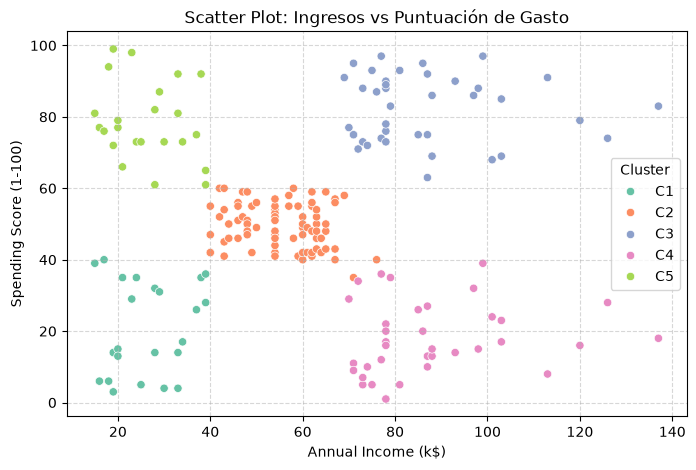

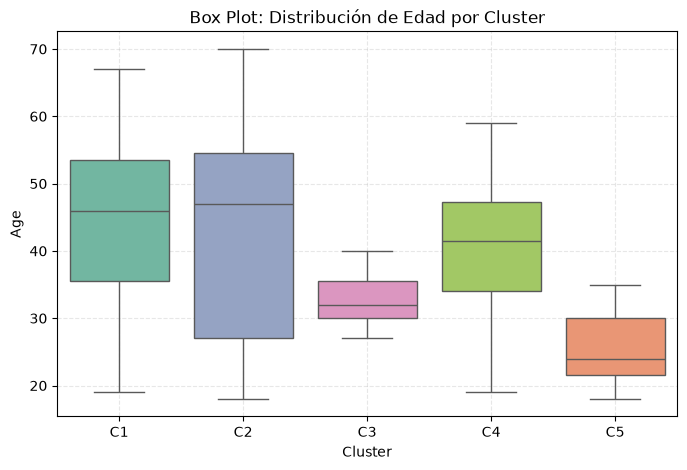

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# =====================================================================
# 1. CARGAR TUS DATOS CON TU RUTA REAL
# =====================================================================
# Añadimos la 'r' al principio para que Windows acepte las barras invertidas
ruta = r"C:\Users\luisr\OneDrive\Desktop\Mall_Customers.csv"
df = pd.read_csv(ruta)

print("¡Datos cargados con éxito desde tu escritorio!")
print(df.head())

# =====================================================================
# 2. SELECCIÓN DE VARIABLES Y K-MEANS
# =====================================================================
# Como vimos en tu archivo de Orange, tus datos ya están normalizados (valores entre 0 y 1)
# Usamos los nombres exactos de tus columnas numéricas
X = df[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']]

# Aplicamos K-Means con los 5 clusters que configuraste en Orange
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# Pasamos los números de cluster a etiquetas tipo Orange (C1, C2...) para los gráficos
df['Cluster'] = df['Cluster'].map({0: 'C1', 1: 'C2', 2: 'C3', 3: 'C4', 4: 'C5'})

# =====================================================================
# 3. GRAFICAR REPLICANDO TU ORANGE (Corregido)
# =====================================================================

# --- SCATTER PLOT --- (Ya te funciona perfecto)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    palette='Set2',
    hue_order=['C1', 'C2', 'C3', 'C4', 'C5']
)
plt.title('Scatter Plot: Ingresos vs Puntuación de Gasto')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- BOX PLOT --- (Corregido para quitar el Warning)
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, 
    x='Cluster', 
    y='Age', 
    hue='Cluster',       # Añadimos hue para que sepa de dónde vienen los colores
    palette='Set2',
    order=['C1', 'C2', 'C3', 'C4', 'C5'],
    legend=False         # Ocultamos la leyenda extra que genera hue en los boxplots
)
plt.title('Box Plot: Distribución de Edad por Cluster')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [8]:
# =====================================================================
# 4. SIMULADOR DE RECOMENDACIONES EN VIVO 
# =====================================================================

def recomendar_estrategia(ingresos, puntuacion_gasto, edad):
    """
    Función que recibe los datos de un cliente nuevo, predice su cluster
    y devuelve la estrategia de marketing recomendada.
    """
    # 1. Creamos un DataFrame con el cliente nuevo. 
    # ES CRUCIAL que tenga exactamente los mismos nombres de columna y orden que el modelo original.
    nuevo_cliente = pd.DataFrame([{
        'Annual Income (k$)': ingresos,
        'Spending Score (1-100)': puntuacion_gasto,
        'Age': edad
    }])
    
    # 2. El modelo predice el cluster numérico (0, 1, 2, 3, 4)
    cluster_predicho = kmeans.predict(nuevo_cliente)[0]
    
    # 3. Lo mapeamos a las etiquetas estilo Orange que creamos antes
    mapeo_clusters = {0: 'C1', 1: 'C2', 2: 'C3', 3: 'C4', 4: 'C5'}
    nombre_cluster = mapeo_clusters[cluster_predicho]
    
    # 4. Diccionario de estrategias de negocio según la posición en tu gráfico
    estrategias = {
        'C1': {
            'Nombre': 'Ahorradores Cuidadosos (Bajos Ingresos / Bajo Gasto)',
            'Accion': 'Ofrecer cupones de descuento básicos y productos de canasta familiar en oferta.'
        },
        'C2': {
            'Nombre': 'Clientes Promedio (Ingresos Medios / Gasto Medio)',
            'Accion': 'Enviar invitaciones a eventos generales del mall y promociones tipo "paga 2 lleva 3" para retenerlos.'
        },
        'C3': {
            'Nombre': 'Clientes VIP (Altos Ingresos / Alto Gasto)',
            'Accion': 'Asignar acceso al lounge exclusivo, lanzamientos de marcas de lujo y preventas VIP.'
        },
        'C4': {
            'Nombre': 'Oportunidad de Oro (Altos Ingresos / Bajo Gasto)',
            'Accion': 'Enviar campañas de retargeting personalizadas de alta calidad. Tienen presupuesto, falta motivarlos.'
        },
        'C5': {
            'Nombre': 'Impulsivos / Cazadores de Tendencias (Bajos Ingresos / Alto Gasto)',
            'Accion': 'Alertas flash en el celular con colecciones de moda rápida y descuentos de tiempo limitado.'
        }
    }
    
    # 5. Imprimir el resultado con diseño limpio para la pantalla
    print("-" * 65)
    print(f"🤖 ANALIZANDO NUEVO CLIENTE EN TIEMPO REAL...")
    print("-" * 65)
    print(f"📍 Datos -> Ingresos: {ingresos}k$ | Gasto: {puntuacion_gasto}/100 | Edad: {edad} años")
    print(f"📊 Cluster Asignado: {nombre_cluster} - {estrategias[nombre_cluster]['Nombre']}")
    print(f"🎯 Estrategia Corporativa: {estrategias[nombre_cluster]['Accion']}")
    print("-" * 65)

# ---------------------------------------------------------------------
# ¡PRUEBA AQUÍ EN VIVO EN TU PRESENTACIÓN!
# ---------------------------------------------------------------------
# Simulemos un cliente con Altos Ingresos (120k), Bajo Gasto (15) y 45 años:
recomendar_estrategia(ingresos=120, puntuacion_gasto=15, edad=45)

-----------------------------------------------------------------
🤖 ANALIZANDO NUEVO CLIENTE EN TIEMPO REAL...
-----------------------------------------------------------------
📍 Datos -> Ingresos: 120k$ | Gasto: 15/100 | Edad: 45 años
📊 Cluster Asignado: C4 - Oportunidad de Oro (Altos Ingresos / Bajo Gasto)
🎯 Estrategia Corporativa: Enviar campañas de retargeting personalizadas de alta calidad. Tienen presupuesto, falta motivarlos.
-----------------------------------------------------------------


In [9]:
pip install streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------- ----------------------------- 2.4/9.2 MB 11.9 MB/s eta 0:00:01
   --------------------- ------------------ 5.0/9.2 MB 11.9 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.2 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 11.3 MB/s  0:00:00
   ---------------------------------------- 0.0/797.5 kB ? eta -:--:--
   ---------------------------------------- 797.5/797.5 kB 10.1 MB/s  0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -------- ------------------------------- 2.4/11.3 MB 11.9 MB/s eta 0:00:01
   ----------------- ---------------------- 5.0/11.3 MB 11.8 MB/s eta 0:00:01
   ------------------------- -------------- 7.3/11.3 MB 11.8 MB/s eta 0:00:01
   ----------------------------------- ---- 10.0/11.3 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 11.3 MB/s  0:00:01
   ---------------